# Introdução à Inteligência Artificial e Fundamentos de Python

## Árvore de Decisão (Decision Tree)

A indução de árvores de decisão é o processo de construção de uma árvore de decisão mediante a divisão de um conjunto de dados de treinamento em subconjuntos menores, utilizando as características de entrada mais úteis e repetindo esse particionamento recursivo até que novas divisões deixem de melhorar as previsões.

Considere com exemplo uma situação na qual precisa-se decidir se alguém irá jogar tênis com base nas condições climáticas, como mostradas na tabela abaixo para uma sequência de 10 dias:

| Dia | Céu        | Temperatura | Umidade | Vento | Jogar? |
| --- | ---------- | ----------: | ------: | ----- | ------ |
| 1   | Ensolarado |          30 |      70 | Fraco | Não    |
| 2   | Ensolarado |          28 |      80 | Forte | Não    |
| 3   | Nublado    |          25 |      65 | Fraco | Sim    |
| 4   | Chuvoso    |          20 |      90 | Fraco | Não    |
| 5   | Chuvoso    |          22 |      75 | Fraco | Sim    |
| 6   | Nublado    |          27 |      70 | Forte | Sim    |
| 7   | Ensolarado |          32 |      60 | Fraco | Sim    |
| 8   | Chuvoso    |          23 |      85 | Forte | Não    |
| 9   | Nublado    |          24 |      68 | Fraco | Sim    |
| 10  | Ensolarado |          29 |      72 | Forte | Não    |

Com esta tabela, tentamos criar uma sequência de regras para decidir se a pessoa ira jogar. Por exemplo, 

              Céu?
             /    \
       Nublado   Ensolarado
          |        /     \
         SIM     Umidade  ?               
                 /    \
              <=70    >70
               |       |
              SIM      NÃO

A árvore de decisão tenta encontrar perguntas que dividam os dados em grupos cada vez mais "puros". Na árvore de decisão, cada **nó** faz uma pergunta, cada **ramo** representa uma resposta, e cada **folha** uma decisão final. 

            Céu = Nublado?
             /          \
           SIM           NÃO
            |             |
           SIM        Umidade <= 70?
                         /       \
                       SIM       NÃO
                        |         |
                       SIM        NÃO

                       
Portanto, uma árvore de decisão é essencialmente um conjunto de regras. Em Python, poderíamos escrever:
  

In [ ]:
if céu == "Nublado":
    jogar = "Sim"
else:
    if umidade <= 70:
        jogar = "Sim"
    else:
        jogar = "Não"

### Critérios de Divisão

Árvores de decisão dividem os dados com base em critérios específicos para determinar o melhor atributo para a partição. Critérios comuns incluem:
* Índice de Gini: Mede a impureza em um conjunto de dados.
* Entropia: Mede o grau de desordem ou incerteza no conjunto de dados.

### Pureza, Entropia, Ganho de Informação e Índice de Gini
Entropia e índice de Gini são medidas do grau de incerteza ou aleatoriedade nos dados. Quanto mais alta a Entropia ou o Índice de Gini, maior a incerteza. Considere como exemplo uma cesta de frutas, onde se tem alguma quantidade de ameixas  e maçãs. Se a cesta contém apenas ameixas, então, no evento de se retirar uma fruta da cesta, não há incerteza alguma sobre a identidade desta. Tanto a Entropia quando o Índice de Gini são zero. Por outro lado, se houver igual número de ameixas e maçãs, ao retirar aleatoriamente uma fruta do cesto, ela será uma maçã ou uma ameixa com igual probabilidade de ser uma ou outra. A Entropia e o índice de Gini são máximos, refletindo a total incerteza sobre o resultado do evento. As expressões para o cálculo da Entropia e do índice de Gini são
$$ Entropia= -\sum_i^n p_i\log_2(p_i),\;\text{e}$$
$$Gini=1-\sum_i^n p_i^2.$$
Nas expressões acima, $p_i$ é a probabilidade de randomicamente ter como resultado um elemento da classe *i*. Assim podemos ver que, segundo o exemplo citado, quando existe igual número de maçãs e ameixas no balde os valores de entropia e do índice de Gini serão:
$$ Entropia =-0.5\log_2(0.5)-0.5\log_2(0.5)=1\Rightarrow 0\le Entropia \le 1,\;\text{e}$$
$$Gini=1-0.5^2-0.5^2=0.5\Rightarrow 0\le Gini\le 0.5.$$

Em uma árvore de decisão, um **grupo** é um conjunto de amostras resultantes de uma divisão binária, ou seja, toda divisão binária resulta em dois grupos. Se para um grupo temos SIM=4 e NÃO=0, então $ Gini=0$, um **grupo perfeitamente puro** e neste caso temos uma **Folha**,ou seja,  um nó que não será mais dividido. Para SIM=2 e NÃO=2, $Gini=0.5$, o maior valor possível para duas classes. Se o critério utilizado é a **entropia**, por outro lado, o objetivo é reduzir a incerteza (quantificada pela entropia) quando o nó é dividido, fazendo os dados resultantes mais previsíveis. O **ganho de informação** é calculado como a diferença entre a entropia antes e depois da divisão. Quanto maior o ganho de informação,melhor é a divisão. Continuaremos este texto utilizando o *Índice de Gini* como critério de escolha de divisões.
A tabela abaixo mostra os valores de Gini para várias distribuições de proporção:

| Distribuição  |  Gini |
| ------------- | ----: |
| 4 SIM / 0 NÃO |     0 |
| 3 SIM / 1 NÃO | 0,375 |
| 2 SIM / 2 NÃO |   0,5 |
| 1 SIM / 3 NÃO | 0,375 |
| 0 SIM / 4 NÃO |     0 |

Finalmente, quanto menor o Gini mais puro é o nó.  No exemplo da decisão sobre jogar tênis, inicialmente todos os 10 dias formam um grupo: Neste grupo, existem 5 SIM e 5 NÃO, e portanto $Gini=0.5$. Em seguida, faz-se uma divisão com a pergunta 

                    TODOS OS DIAS
                         |
                  Céu = Nublado?
                    /           \
                  SIM            NÃO
                  |               |
                Grupo A         Grupo B

Para o grupo A temos os dias em que o céu encontra-se nublado: 

| Dia | Céu     | Umidade | Vento | Jogar |
| --- | ------- | ------: | ----- | ----- |
| 3   | Nublado |      65 | Fraco | Sim   |
| 6   | Nublado |      70 | Forte | Sim   |
| 9   | Nublado |      68 | Fraco | Sim   |

Este é um grupo puro, pois $Gini=0$. Para os dias não nublados, temos:

| Dia | Céu        | Umidade | Vento | Jogar |
| --- | ---------- | ------: | ----- | ----- |
| 1   | Ensolarado |      70 | Fraco | Não   |
| 2   | Ensolarado |      80 | Forte | Não   |
| 4   | Chuvoso    |      90 | Fraco | Não   |
| 5   | Chuvoso    |      75 | Fraco | Sim   |
| 7   | Ensolarado |      60 | Fraco | Sim   |
| 8   | Chuvoso    |      85 | Forte | Não   |
| 10  | Ensolarado |      72 | Forte | Não   |

Com 5 Não e 2 SIM. Este grupo ainda é impuro. Para avaliar a qualidade desta divisão o Gini de cada grupo é calculado e é feita uma **média poderada pelo número de elementos**: 
$$Gini=\frac{N_A}{N}Gini_A+\frac{N_B}{N}Gini_B$$

Assim teremos
$$Gini=\frac{3}{10}Gini_A+\frac{7}{10}Gini_B=\frac{7}{10}Gini_B,$$
pois o grupo A é perfeitamente puro. Neste caso, o grupo A é uma folha e não será mais dividido. Na sequência o Grupo B segue sendo dividido. No algoritmo básico a árvore procura as divisões que produzam o menor Gini ponderado:

<div>
<img src="Imagens\ChatGPT DecisionTree.png" width="400" height="700">   
</div>
Fonte: imagem gerada por IA



### **Exemplo** 
Vamos continuar com o exemplo da decisão de jogar ou não jogar tênis com base nas condições climáticas. No primeiro passo, definimos um dicionário com base nos dados da tabela inicial:


In [1]:
dataset_dict = {
    'Céu': ['ensolarado', 'ensolarado', 'nublado', 'chuvoso', 'chuvoso', 'nublado', 'ensolarado', 'chuvoso', 'nublado', 'ensolarado'],
    'Temperatura': [30, 28, 25, 20, 22, 27, 32, 23, 24, 29],
    'Humidade': [70, 80, 65, 90, 75, 70, 60, 85, 68, 72],
    'Vento': ['fraco', 'forte', 'fraco', 'fraco', 'fraco', 'forte', 'fraco', 'forte', 'fraco', 'forte'],
    'Jogar?': ['não', 'não', 'sim', 'não', 'sim', 'sim', 'sim', 'não', 'sim', 'não']
}

Em seguida, usamos a biblioteca `pandas`para transformar o dicionário em um *DataFrame*. Um DataFrame do `Pandas` é uma estrutura de dados bidimensional semelhante a uma tabela, utilizada no Python, na qual os dados são organizados em linhas e colunas. É uma das ferramentas mais utilizadas para lidar com dados, facilitando sua organização, análise e manipulação. Ele permite armazenar diferentes tipos de dados — como números, textos e datas — em suas colunas Uma excelente introdução com muitos exemplos é encontrada aqui:
https://www.geeksforgeeks.org/pandas/python-pandas-dataframe/.

In [2]:
import pandas as pd
df = pd.DataFrame(dataset_dict)
print(df)

          Céu  Temperatura  Humidade  Vento Jogar?
0  ensolarado           30        70  fraco    não
1  ensolarado           28        80  forte    não
2     nublado           25        65  fraco    sim
3     chuvoso           20        90  fraco    não
4     chuvoso           22        75  fraco    sim
5     nublado           27        70  forte    sim
6  ensolarado           32        60  fraco    sim
7     chuvoso           23        85  forte    não
8     nublado           24        68  fraco    sim
9  ensolarado           29        72  forte    não


Definimos agora uma função para o cálculo do *Gini* em duas categorias.

In [3]:
def gini(grupo):
    total = len(grupo)
    
    sim = sum(grupo == 'sim')
    nao = sum(grupo == 'não')

    p_sim = sim / total
    p_nao = nao / total

    return 1 - p_sim**2 - p_nao**2

Cálculo do Gini antes de qualquer divisão:

In [4]:
gini_total = gini(df['Jogar?'])
print(gini_total)

0.5


Segundo a tabela `df`, há 5 saídas NÃO e 5 saídas SIM. Portanto, estamos com máxima incerteza, justificando o resposta $Gini=0.5$. Vamos testar a primeira divisão com a pergunta `Céu=nublado`?

In [5]:
grupo_sim = df[df['Céu'] == 'nublado']
grupo_nao = df[df['Céu'] != 'nublado']
print("Grupo SIM:")
print(grupo_sim)

print("\nGrupo NÃO:")
print(grupo_nao)

Grupo SIM:
       Céu  Temperatura  Humidade  Vento Jogar?
2  nublado           25        65  fraco    sim
5  nublado           27        70  forte    sim
8  nublado           24        68  fraco    sim

Grupo NÃO:
          Céu  Temperatura  Humidade  Vento Jogar?
0  ensolarado           30        70  fraco    não
1  ensolarado           28        80  forte    não
3     chuvoso           20        90  fraco    não
4     chuvoso           22        75  fraco    sim
6  ensolarado           32        60  fraco    sim
7     chuvoso           23        85  forte    não
9  ensolarado           29        72  forte    não


E calculamos o Gini de cada grupo:

In [6]:
gini_sim = gini(grupo_sim['Jogar?'])
print('Gini Grupo SIM=', gini_sim)

gini_nao = gini(grupo_nao['Jogar?'])
print('Gini Grupo NÃO=',gini_nao)

Gini Grupo SIM= 0.0
Gini Grupo NÃO= 0.40816326530612246


Média Ponderada do Gini

In [7]:
total = len(df)
gini_split = (len(grupo_sim) / total * gini_sim+len(grupo_nao) / total * gini_nao)
print(gini_split)

0.2857142857142857


O conjunto original tinha Gini=0.5. Com esta divisão o índice reduziu para 0.286, melhorando o grau de pureza. Implementaremos agora uma função para o cálculo do Gini e Gini ponderado:

In [8]:
def avaliar_split(grupo1, grupo2):

    total = len(grupo1) + len(grupo2)

    gini1 = gini(grupo1['Jogar?'])
    gini2 = gini(grupo2['Jogar?'])

    gini_split = (len(grupo1) / total * gini1 +len(grupo2) / total * gini2 )

    print("Grupo 1:", len(grupo1), "elementos")
    print("Gini 1:", round(gini1, 3))

    print("Grupo 2:", len(grupo2), "elementos")
    print("Gini 2:", round(gini2, 3))

    print("Gini do split:", round(gini_split, 3))

Divisão pela varável **Céu**

In [9]:
grupo1 = df[df['Céu'] == 'nublado']
grupo2 = df[df['Céu'] != 'nublado']

avaliar_split(grupo1, grupo2)

Grupo 1: 3 elementos
Gini 1: 0.0
Grupo 2: 7 elementos
Gini 2: 0.408
Gini do split: 0.286


E testamos agora a divisão pela variável **Humidade**

In [10]:
grupo1 = df[df['Humidade'] <= 70]
print(grupo1)
grupo2 = df[df['Humidade'] > 70]
print(grupo2)

avaliar_split(grupo1, grupo2)

          Céu  Temperatura  Humidade  Vento Jogar?
0  ensolarado           30        70  fraco    não
2     nublado           25        65  fraco    sim
5     nublado           27        70  forte    sim
6  ensolarado           32        60  fraco    sim
8     nublado           24        68  fraco    sim
          Céu  Temperatura  Humidade  Vento Jogar?
1  ensolarado           28        80  forte    não
3     chuvoso           20        90  fraco    não
4     chuvoso           22        75  fraco    sim
7     chuvoso           23        85  forte    não
9  ensolarado           29        72  forte    não
Grupo 1: 5 elementos
Gini 1: 0.32
Grupo 2: 5 elementos
Gini 2: 0.32
Gini do split: 0.32


Até este momento, a divisão por `Céu=nublado`é melhor, pois resultou em um grau de pureza maior. Testando a variável **Vento**, temos

In [11]:
grupo1 = df[df['Vento'] == 'fraco']
print(grupo1)
grupo2 = df[df['Vento'] == 'forte']
print(grupo2)
avaliar_split(grupo1, grupo2)

          Céu  Temperatura  Humidade  Vento Jogar?
0  ensolarado           30        70  fraco    não
2     nublado           25        65  fraco    sim
3     chuvoso           20        90  fraco    não
4     chuvoso           22        75  fraco    sim
6  ensolarado           32        60  fraco    sim
8     nublado           24        68  fraco    sim
          Céu  Temperatura  Humidade  Vento Jogar?
1  ensolarado           28        80  forte    não
5     nublado           27        70  forte    sim
7     chuvoso           23        85  forte    não
9  ensolarado           29        72  forte    não
Grupo 1: 6 elementos
Gini 1: 0.444
Grupo 2: 4 elementos
Gini 2: 0.375
Gini do split: 0.417


Em um dos grupos, o Gini resultou em 0.374, um valor razoavelmente bom, enquanto no outro o resultado foi pior, 0.444. Podemos concluir que uma boa divisão é aquela que produz **grupos mais puros**.  Finalmente testamos a **temperatura**.

In [12]:
grupo1 = df[df['Temperatura'] <= 25]
print(grupo1)
grupo2 = df[df['Temperatura'] > 25]
print(grupo2)

avaliar_split(grupo1, grupo2)

       Céu  Temperatura  Humidade  Vento Jogar?
2  nublado           25        65  fraco    sim
3  chuvoso           20        90  fraco    não
4  chuvoso           22        75  fraco    sim
7  chuvoso           23        85  forte    não
8  nublado           24        68  fraco    sim
          Céu  Temperatura  Humidade  Vento Jogar?
0  ensolarado           30        70  fraco    não
1  ensolarado           28        80  forte    não
5     nublado           27        70  forte    sim
6  ensolarado           32        60  fraco    sim
9  ensolarado           29        72  forte    não
Grupo 1: 5 elementos
Gini 1: 0.48
Grupo 2: 5 elementos
Gini 2: 0.48
Gini do split: 0.48


Podemos finalmente escrever uma função que testa divisões para todos os limiares de corte de uma variável, automatizando o algoritmo.

In [13]:
import numpy as np
def divis_automatica(variavel):
    valores = sorted(df[variavel].unique())
    gini_lst=[]

    for valor in valores:   
        grupo1 = df[df[variavel] <= valor]
        grupo2 = df[df[variavel] > valor]
    
        if len(grupo1) > 0 and len(grupo2) > 0:  
            total = len(df)    
            gini_split = (len(grupo1) / total * gini(grupo1['Jogar?'])+len(grupo2) / total * gini(grupo2['Jogar?']))
            gini_lst.append(gini_split)
    
            print(variavel+"<=", valor,"→ Gini =", round(gini_split, 3))
    print("\nO melhor limiar é ", valores[np.argmin(gini_lst)])

In [14]:
divis_automatica('Humidade')

Humidade<= 60 → Gini = 0.444
Humidade<= 65 → Gini = 0.375
Humidade<= 68 → Gini = 0.286
Humidade<= 70 → Gini = 0.32
Humidade<= 72 → Gini = 0.417
Humidade<= 75 → Gini = 0.286
Humidade<= 80 → Gini = 0.375
Humidade<= 85 → Gini = 0.444

O melhor limiar é  68


In [15]:
divis_automatica('Temperatura')

Temperatura<= 20 → Gini = 0.444
Temperatura<= 22 → Gini = 0.5
Temperatura<= 23 → Gini = 0.476
Temperatura<= 24 → Gini = 0.5
Temperatura<= 25 → Gini = 0.48
Temperatura<= 27 → Gini = 0.417
Temperatura<= 28 → Gini = 0.476
Temperatura<= 29 → Gini = 0.5
Temperatura<= 30 → Gini = 0.444

O melhor limiar é  27


Na implementação das árvores, os pontos de corte relevantes para uma variável numérica são determinados a partir dos valores observados nos dados, e não é necessário testar arbitrariamente todos os números possíveis. 
A cada etapa, a árvore avalia todos os atributos possíveis para realizar a divisão e utiliza o Ganho de Informação para escolher aquele que mais reduz a incerteza. Este processo está resumido graficamente na figura abaixo:


<div>
<img src="Imagens\ChatGPT Split.png" width="400" height="700">   
</div>
Fonte: imagem gerada por IA

### **Exemplo** Aplicação ao conjunto Íris de Dados

In [16]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)
print(y.shape)

print(iris.feature_names)

(150, 4)
(150,)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


Como discutimos na aula anterior, este *dataset* possui 4 caracteristicas, ou seja, o comprimento e a largura da sépala e o comprimento e a largura da pétala, além de três classes, setosa, virginica e versicolor. Vamos restringir o conjunto a apenas duas características, comprimento e largura da sépala:

In [17]:
X = iris.data[:, [0, 1]]
y = iris.target
print(iris.feature_names[0:2])

['sepal length (cm)', 'sepal width (cm)']


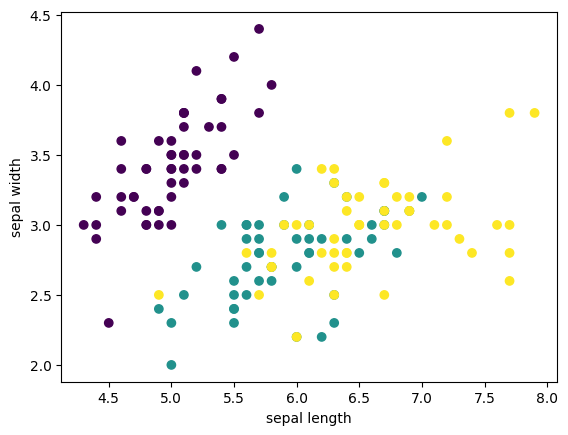

In [18]:
# visualização
import matplotlib.pyplot as plt

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y
)

plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.show()

Criação da árvore de decisão

In [19]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    # Índice de Gini para medição de impureza
    criterion="gini",
    # Profundidade máxima da árvore
    max_depth=4,
    random_state=42
)

model.fit(X, y)

DecisionTreeClassifier(max_depth=4, random_state=42)

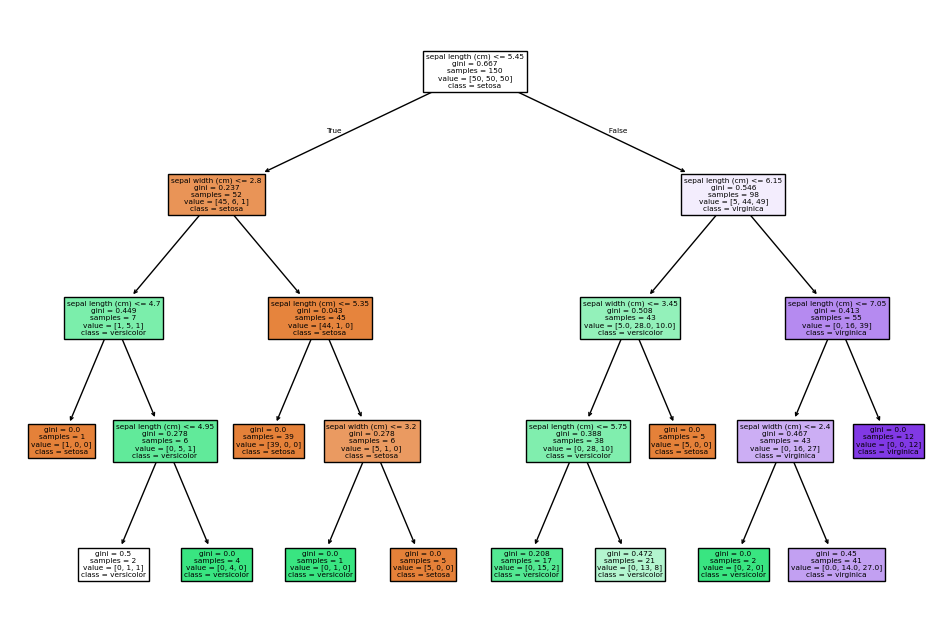

In [20]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names = [
    iris.feature_names[0],
    iris.feature_names[1]
],
    class_names=iris.target_names,
    filled=True
)

plt.show()

Fazendo previsões:

In [21]:
print("Treinamento:", model.score(X, y))

Treinamento: 0.8333333333333334


In [22]:
new = [[2.5, 2]]
prediction = model.predict(new)
print(prediction)

[0]


In [23]:
print(iris.target_names[prediction][0])

setosa


Finalmente, abaixo testamos o algoritmo considerando as 4 características:

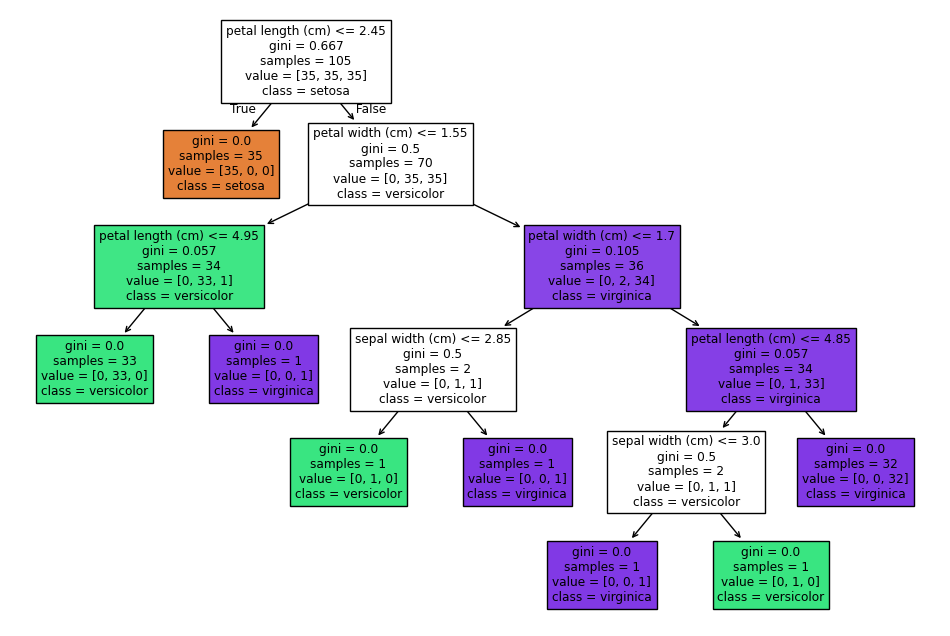

In [24]:
X = iris.data
y = iris.target

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names = iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()



In [25]:
print("Treinamento:", model.score(X_train, y_train))
print("Teste:", model.score(X_test, y_test))

Treinamento: 1.0
Teste: 0.9333333333333333


Por que a árvore conseguiu 100% no treinamento, mas não 100% no teste?